# Pertemuan 10: Algoritma Klasifikasi (Bagian 2)

**Mata Kuliah:** Data Science (200302305)
**Program Studi:** PJJ Informatika, Semester 4
**Dosen Pengampu:** Syahid Abdullah, S.Si, M.Kom

| Keterangan | Isi |
| --- | --- |
| Nama Lengkap | [ISI NAMA LENGKAP ANDA] |
| NIM | [ISI NIM ANDA] |
| Kelas | [ISI KELAS ANDA] |

**Topik:** Metode Ensemble (Random Forest), Penanganan Imbalanced Dataset, dan Studi Kasus Customer Churn Prediction


## 1. Tujuan Praktikum

1. Memahami konsep metode ensemble, khususnya bagging pada Random Forest.
2. Mengenali masalah yang muncul pada dataset tidak seimbang (imbalanced dataset).
3. Menerapkan dua strategi penanganan, yaitu pembobotan kelas dan oversampling.
4. Mengerjakan studi kasus Customer Churn Prediction beserta interpretasi metriknya.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, roc_auc_score, roc_curve,
    precision_recall_curve
)

%matplotlib inline
sns.set_theme(style='whitegrid')
plt.rcParams['figure.dpi'] = 110
RANDOM_STATE = 42
rng = np.random.default_rng(RANDOM_STATE)

print('Pustaka berhasil dimuat.')

Pustaka berhasil dimuat.


## 2. Membangun Dataset Customer Churn

Dataset customer churn dibangkitkan secara terprogram memakai generator acak dengan
seed tetap. Cara ini dipilih agar notebook dapat dijalankan ulang oleh siapa pun tanpa
memerlukan berkas eksternal, sementara karakteristik datanya tetap menyerupai data
pelanggan layanan telekomunikasi yang sebenarnya, termasuk sifatnya yang tidak seimbang.

Peluang seorang pelanggan berhenti berlangganan disusun agar dipengaruhi oleh masa
berlangganan, besar tagihan bulanan, jenis kontrak, jumlah panggilan ke layanan
dukungan, dan jumlah layanan tambahan yang diambil.

In [2]:
n = 4000

tenure = rng.integers(1, 73, size=n)                       # lama berlangganan dalam bulan
monthly_charges = np.round(rng.normal(70, 22, size=n).clip(20, 130), 2)
kontrak = rng.choice(['Bulanan', 'Satu Tahun', 'Dua Tahun'], size=n, p=[0.55, 0.27, 0.18])
support_calls = rng.poisson(1.4, size=n).clip(0, 12)
layanan_tambahan = rng.integers(0, 7, size=n)
metode_bayar = rng.choice(['Transfer Bank', 'Kartu Kredit', 'Tagihan Elektronik'], size=n, p=[0.35, 0.33, 0.32])

total_charges = np.round(monthly_charges * tenure * rng.uniform(0.93, 1.07, size=n), 2)

# Menyusun peluang churn berdasarkan kombinasi faktor risiko
bobot_kontrak = pd.Series(kontrak).map({'Bulanan': 1.15, 'Satu Tahun': -0.35, 'Dua Tahun': -0.95}).to_numpy()
bobot_bayar = pd.Series(metode_bayar).map({'Tagihan Elektronik': 0.45, 'Transfer Bank': -0.1, 'Kartu Kredit': -0.2}).to_numpy()

skor = (
    -2.75
    - 0.045 * tenure
    + 0.022 * (monthly_charges - 70)
    + 0.30 * support_calls
    - 0.16 * layanan_tambahan
    + bobot_kontrak
    + bobot_bayar
    + rng.normal(0, 0.55, size=n)
)
peluang = 1 / (1 + np.exp(-skor))
churn = (rng.random(n) < peluang).astype(int)

df = pd.DataFrame({
    'tenure_bulan': tenure,
    'tagihan_bulanan': monthly_charges,
    'total_tagihan': total_charges,
    'jenis_kontrak': kontrak,
    'metode_pembayaran': metode_bayar,
    'panggilan_dukungan': support_calls,
    'layanan_tambahan': layanan_tambahan,
    'churn': churn,
})

print('Ukuran dataset:', df.shape)
df.head(10)

Ukuran dataset: (4000, 8)


,tenure_bulan,tagihan_bulanan,total_tagihan,jenis_kontrak,metode_pembayaran,panggilan_dukungan,layanan_tambahan,churn
0,7,47.46,352.62,Bulanan,Kartu Kredit,0,1,0
1,56,89.98,4716.07,Satu Tahun,Kartu Kredit,5,1,0
2,48,43.54,2230.85,Bulanan,Tagihan Elektronik,3,0,0
3,32,63.70,2077.68,Dua Tahun,Transfer Bank,1,4,0
4,32,57.11,1710.67,Dua Tahun,Tagihan Elektronik,2,2,0
5,62,73.62,4496.47,Bulanan,Transfer Bank,2,3,0
6,7,55.91,378.12,Dua Tahun,Transfer Bank,1,3,0
7,51,64.04,3402.56,Dua Tahun,Tagihan Elektronik,0,5,0
8,15,64.81,934.78,Bulanan,Kartu Kredit,0,5,0
9,7,53.84,394.09,Bulanan,Kartu Kredit,0,3,0


In [3]:
print(df.info())
print()
print('Jumlah nilai kosong per kolom:')
print(df.isna().sum())

<class 'pandas.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   tenure_bulan        4000 non-null   int64  
 1   tagihan_bulanan     4000 non-null   float64
 2   total_tagihan       4000 non-null   float64
 3   jenis_kontrak       4000 non-null   str    
 4   metode_pembayaran   4000 non-null   str    
 5   panggilan_dukungan  4000 non-null   int64  
 6   layanan_tambahan    4000 non-null   int64  
 7   churn               4000 non-null   int64  
dtypes: float64(2), int64(4), str(2)
memory usage: 250.1 KB
None

Jumlah nilai kosong per kolom:
tenure_bulan          0
tagihan_bulanan       0
total_tagihan         0
jenis_kontrak         0
metode_pembayaran     0
panggilan_dukungan    0
layanan_tambahan      0
churn                 0
dtype: int64


## 3. Analisis Ketidakseimbangan Kelas

Pelanggan bertahan (0): 3836 (95.90 persen)
Pelanggan berhenti (1): 164 (4.10 persen)
Rasio kelas minoritas terhadap mayoritas: 1 berbanding 23.4


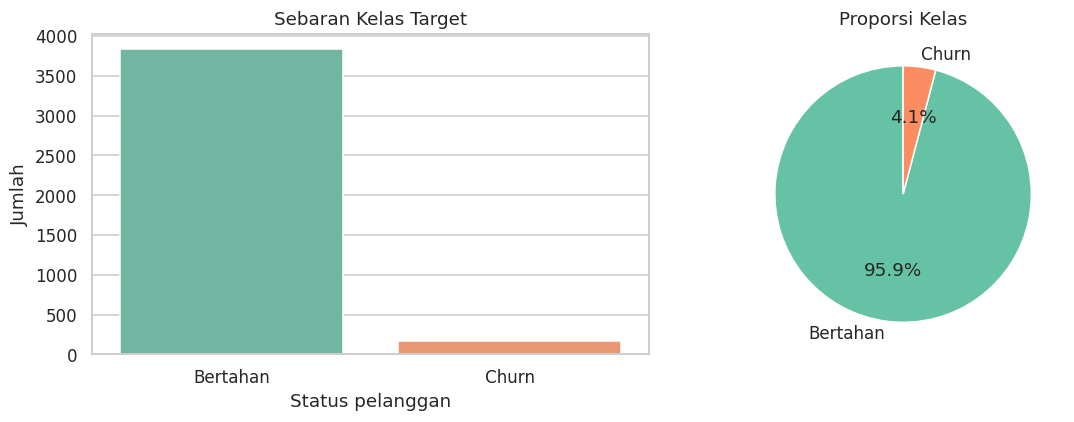

In [4]:
jumlah_churn = df['churn'].value_counts().sort_index()
rasio = jumlah_churn[1] / jumlah_churn[0]

print('Pelanggan bertahan (0):', jumlah_churn[0], f'({jumlah_churn[0] / len(df) * 100:.2f} persen)')
print('Pelanggan berhenti (1):', jumlah_churn[1], f'({jumlah_churn[1] / len(df) * 100:.2f} persen)')
print(f'Rasio kelas minoritas terhadap mayoritas: 1 berbanding {1 / rasio:.1f}')

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
sns.countplot(x=df['churn'].map({0: 'Bertahan', 1: 'Churn'}),
              hue=df['churn'].map({0: 'Bertahan', 1: 'Churn'}),
              palette='Set2', legend=False, ax=axes[0])
axes[0].set_title('Sebaran Kelas Target')
axes[0].set_xlabel('Status pelanggan')
axes[0].set_ylabel('Jumlah')

axes[1].pie(jumlah_churn, labels=['Bertahan', 'Churn'], autopct='%1.1f%%',
            colors=['#66c2a5', '#fc8d62'], startangle=90)
axes[1].set_title('Proporsi Kelas')
plt.tight_layout()
plt.show()

Kelas minoritas hanya menempati sekitar seperlima dari keseluruhan data. Inilah yang
disebut **imbalanced dataset**. Konsekuensinya, sebuah model yang selalu menebak
"bertahan" untuk semua pelanggan sudah otomatis memperoleh akurasi sekitar delapan
puluh persen tanpa mempelajari apa pun. Akurasi setinggi itu jelas menyesatkan karena
model tersebut sama sekali tidak berguna bagi bisnis.

In [5]:
# Model naif sebagai pembanding: selalu memprediksi kelas mayoritas
akurasi_naif = (df['churn'] == 0).mean()
print(f'Akurasi model yang selalu menebak "bertahan": {akurasi_naif:.4f}')
print('Recall model tersebut pada kelas churn: 0.0000')
print('Inilah alasan Accuracy tidak boleh dipakai sendirian pada data yang tidak seimbang.')

Akurasi model yang selalu menebak "bertahan": 0.9590
Recall model tersebut pada kelas churn: 0.0000
Inilah alasan Accuracy tidak boleh dipakai sendirian pada data yang tidak seimbang.


## 4. Eksplorasi Faktor Penyebab Churn

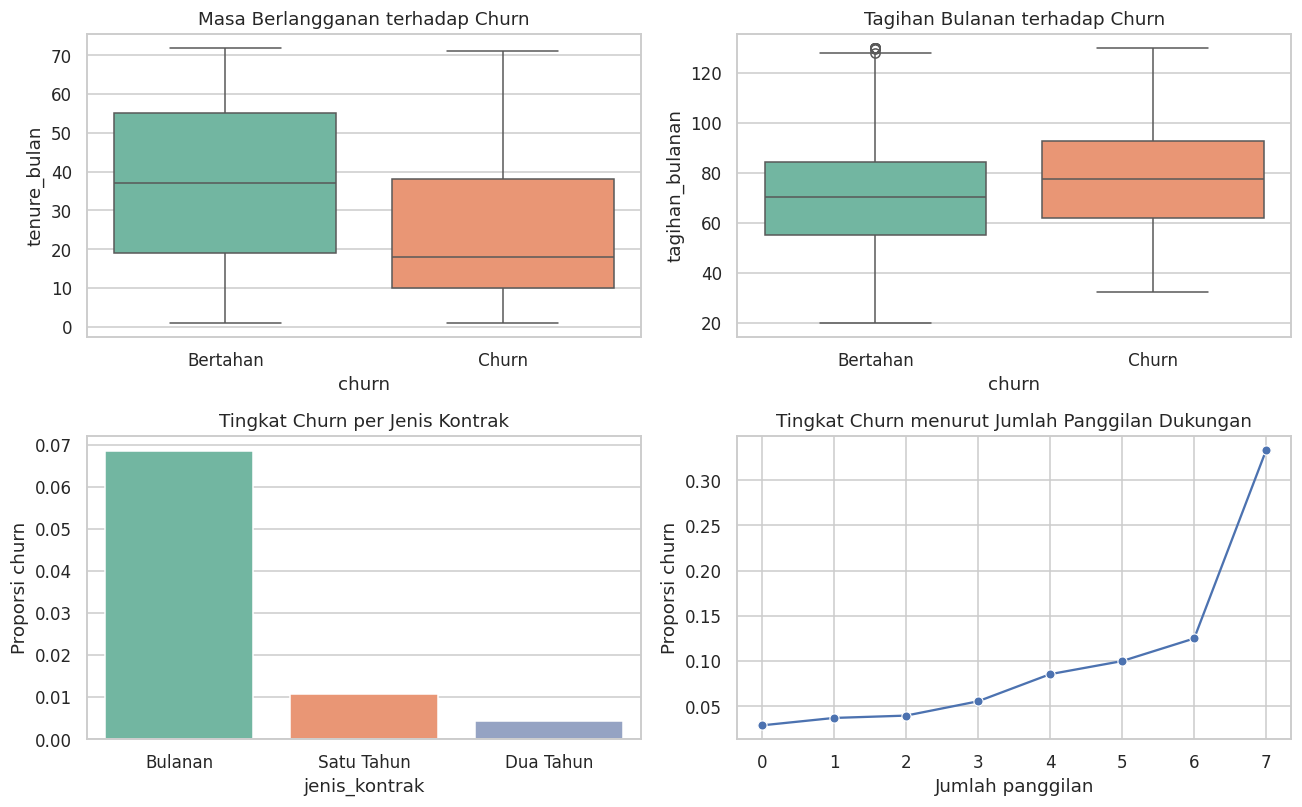

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7.5))

sns.boxplot(data=df, x='churn', y='tenure_bulan', hue='churn', palette='Set2', legend=False, ax=axes[0, 0])
axes[0, 0].set_title('Masa Berlangganan terhadap Churn')
axes[0, 0].set_xticks([0, 1])
axes[0, 0].set_xticklabels(['Bertahan', 'Churn'])

sns.boxplot(data=df, x='churn', y='tagihan_bulanan', hue='churn', palette='Set2', legend=False, ax=axes[0, 1])
axes[0, 1].set_title('Tagihan Bulanan terhadap Churn')
axes[0, 1].set_xticks([0, 1])
axes[0, 1].set_xticklabels(['Bertahan', 'Churn'])

kontrak_churn = df.groupby('jenis_kontrak')['churn'].mean().sort_values(ascending=False)
sns.barplot(x=kontrak_churn.index, y=kontrak_churn.values, hue=kontrak_churn.index,
            palette='Set2', legend=False, ax=axes[1, 0])
axes[1, 0].set_title('Tingkat Churn per Jenis Kontrak')
axes[1, 0].set_ylabel('Proporsi churn')

panggilan_churn = df.groupby('panggilan_dukungan')['churn'].mean()
sns.lineplot(x=panggilan_churn.index, y=panggilan_churn.values, marker='o', ax=axes[1, 1])
axes[1, 1].set_title('Tingkat Churn menurut Jumlah Panggilan Dukungan')
axes[1, 1].set_xlabel('Jumlah panggilan')
axes[1, 1].set_ylabel('Proporsi churn')

plt.tight_layout()
plt.show()

## 5. Persiapan Data

Kolom kategorik diubah menjadi kolom numerik memakai one hot encoding melalui
`pd.get_dummies`, kemudian data dibagi dengan `stratify` agar proporsi kelas tetap
terjaga pada data latih maupun data uji.

In [7]:
X = pd.get_dummies(df.drop(columns='churn'), columns=['jenis_kontrak', 'metode_pembayaran'], drop_first=True)
y = df['churn']

print('Kolom setelah encoding:')
print(list(X.columns))

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=RANDOM_STATE, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print()
print('Data latih:', X_train.shape, 'dengan churn', int(y_train.sum()), 'baris')
print('Data uji  :', X_test.shape, 'dengan churn', int(y_test.sum()), 'baris')

Kolom setelah encoding:
['tenure_bulan', 'tagihan_bulanan', 'total_tagihan', 'panggilan_dukungan', 'layanan_tambahan', 'jenis_kontrak_Dua Tahun', 'jenis_kontrak_Satu Tahun', 'metode_pembayaran_Tagihan Elektronik', 'metode_pembayaran_Transfer Bank']

Data latih: (3000, 9) dengan churn 123 baris
Data uji  : (1000, 9) dengan churn 41 baris


## 6. Model Dasar Sebelum Penanganan Ketidakseimbangan

In [8]:
def evaluasi(nama, y_benar, y_prediksi, y_peluang=None, tampilkan=True):
    """Menghitung empat metrik utama dan mengembalikannya sebagai kamus."""
    hasil = {
        'Model': nama,
        'Accuracy': accuracy_score(y_benar, y_prediksi),
        'Precision': precision_score(y_benar, y_prediksi, zero_division=0),
        'Recall': recall_score(y_benar, y_prediksi, zero_division=0),
        'F1-Score': f1_score(y_benar, y_prediksi, zero_division=0),
    }
    if y_peluang is not None:
        hasil['ROC-AUC'] = roc_auc_score(y_benar, y_peluang)
    if tampilkan:
        print(f'{nama}')
        for kunci, nilai in hasil.items():
            if kunci != 'Model':
                print(f'  {kunci:<10}: {nilai:.4f}')
        print()
    return hasil


ringkasan = []

logreg = LogisticRegression(max_iter=5000, random_state=RANDOM_STATE)
logreg.fit(X_train_scaled, y_train)
pred_logreg = logreg.predict(X_test_scaled)
ringkasan.append(evaluasi('Logistic Regression', y_test, pred_logreg, logreg.predict_proba(X_test_scaled)[:, 1]))

tree = DecisionTreeClassifier(max_depth=6, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)
ringkasan.append(evaluasi('Decision Tree', y_test, pred_tree, tree.predict_proba(X_test)[:, 1]))

Logistic Regression
  Accuracy  : 0.9590
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  ROC-AUC   : 0.8140

Decision Tree
  Accuracy  : 0.9550
  Precision : 0.1667
  Recall    : 0.0244
  F1-Score  : 0.0426
  ROC-AUC   : 0.7292



## 7. Metode Ensemble: Random Forest

Random Forest bekerja dengan prinsip **bagging**. Puluhan hingga ratusan Decision Tree
dilatih pada contoh data yang berbeda beda hasil pengambilan ulang, dan pada setiap
percabangan hanya sebagian fitur yang dipertimbangkan. Prediksi akhirnya diambil dari
suara terbanyak seluruh pohon. Keragaman antar pohon inilah yang membuat Random Forest
lebih tahan terhadap gejala menghafal data latih dibandingkan satu pohon tunggal.

In [9]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=3,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)
proba_rf = rf.predict_proba(X_test)[:, 1]

ringkasan.append(evaluasi('Random Forest (tanpa penanganan)', y_test, pred_rf, proba_rf))

Random Forest (tanpa penanganan)
  Accuracy  : 0.9590
  Precision : 0.0000
  Recall    : 0.0000
  F1-Score  : 0.0000
  ROC-AUC   : 0.7265



## 8. Penanganan Imbalanced Dataset

Dua strategi yang diterapkan pada praktikum ini adalah sebagai berikut.

**Strategi pertama, pembobotan kelas.** Parameter `class_weight='balanced'` membuat
kesalahan pada kelas minoritas dihitung lebih mahal, sehingga model terdorong untuk
lebih memperhatikan pelanggan yang berpotensi churn.

**Strategi kedua, random oversampling.** Baris pada kelas minoritas diperbanyak melalui
pengambilan ulang sampai jumlahnya setara dengan kelas mayoritas. Cara ini dikerjakan
langsung memakai numpy dan pandas sehingga tidak memerlukan pustaka tambahan. Teknik
yang lebih maju bernama SMOTE bekerja dengan membangkitkan data sintetis di antara
tetangga terdekat kelas minoritas, dan tersedia pada pustaka `imbalanced-learn`.

Penting untuk dicatat bahwa oversampling **hanya boleh dilakukan pada data latih**.
Bila diterapkan sebelum pembagian data, salinan baris yang sama dapat muncul di data
latih sekaligus data uji sehingga evaluasinya menjadi terlalu optimistis.

In [10]:
# Strategi pertama: pembobotan kelas
rf_bobot = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=3, class_weight='balanced',
    random_state=RANDOM_STATE, n_jobs=-1
)
rf_bobot.fit(X_train, y_train)
pred_rf_bobot = rf_bobot.predict(X_test)
proba_rf_bobot = rf_bobot.predict_proba(X_test)[:, 1]

ringkasan.append(evaluasi('Random Forest (class_weight balanced)', y_test, pred_rf_bobot, proba_rf_bobot))

Random Forest (class_weight balanced)
  Accuracy  : 0.9590
  Precision : 0.5000
  Recall    : 0.0976
  F1-Score  : 0.1633
  ROC-AUC   : 0.7534



In [11]:
# Strategi kedua: random oversampling hanya pada data latih
latih = X_train.copy()
latih['churn'] = y_train.values

mayoritas = latih[latih['churn'] == 0]
minoritas = latih[latih['churn'] == 1]

indeks_tambahan = rng.choice(minoritas.index.to_numpy(), size=len(mayoritas) - len(minoritas), replace=True)
minoritas_diperbanyak = pd.concat([minoritas, latih.loc[indeks_tambahan]])

latih_seimbang = pd.concat([mayoritas, minoritas_diperbanyak]).sample(frac=1, random_state=RANDOM_STATE)

X_train_os = latih_seimbang.drop(columns='churn')
y_train_os = latih_seimbang['churn']

print('Sebelum oversampling:', dict(y_train.value_counts().sort_index()))
print('Sesudah oversampling:', dict(y_train_os.value_counts().sort_index()))

Sebelum oversampling: {0: np.int64(2877), 1: np.int64(123)}
Sesudah oversampling: {0: np.int64(2877), 1: np.int64(2877)}


In [12]:
rf_os = RandomForestClassifier(
    n_estimators=300, min_samples_leaf=3, random_state=RANDOM_STATE, n_jobs=-1
)
rf_os.fit(X_train_os, y_train_os)
pred_rf_os = rf_os.predict(X_test)
proba_rf_os = rf_os.predict_proba(X_test)[:, 1]

ringkasan.append(evaluasi('Random Forest (oversampling)', y_test, pred_rf_os, proba_rf_os))

Random Forest (oversampling)
  Accuracy  : 0.9460
  Precision : 0.1905
  Recall    : 0.0976
  F1-Score  : 0.1290
  ROC-AUC   : 0.7377



## 9. Confusion Matrix Seluruh Model

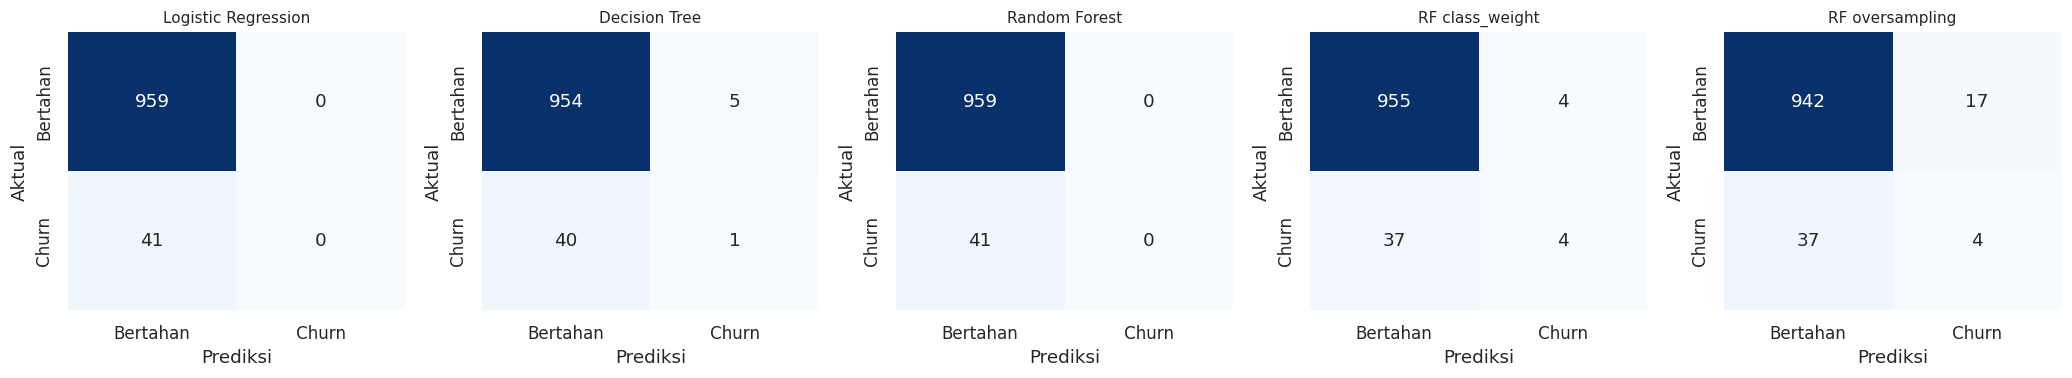

Rincian angka Confusion Matrix
Logistic Regression    TN=959   FP=0     FN=41    TP=0     (churn terlewat: 41)
Decision Tree          TN=954   FP=5     FN=40    TP=1     (churn terlewat: 40)
Random Forest          TN=959   FP=0     FN=41    TP=0     (churn terlewat: 41)
RF class_weight        TN=955   FP=4     FN=37    TP=4     (churn terlewat: 37)
RF oversampling        TN=942   FP=17    FN=37    TP=4     (churn terlewat: 37)


In [13]:
pasangan = [
    ('Logistic Regression', pred_logreg),
    ('Decision Tree', pred_tree),
    ('Random Forest', pred_rf),
    ('RF class_weight', pred_rf_bobot),
    ('RF oversampling', pred_rf_os),
]

fig, axes = plt.subplots(1, 5, figsize=(19, 3.6))
for ax, (nama, pred) in zip(axes, pasangan):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Bertahan', 'Churn'], yticklabels=['Bertahan', 'Churn'])
    ax.set_title(nama, fontsize=10)
    ax.set_xlabel('Prediksi')
    ax.set_ylabel('Aktual')

plt.tight_layout()
plt.show()

print('Rincian angka Confusion Matrix')
for nama, pred in pasangan:
    tn, fp, fn, tp = confusion_matrix(y_test, pred).ravel()
    print(f'{nama:<22} TN={tn:<5} FP={fp:<5} FN={fn:<5} TP={tp:<5} (churn terlewat: {fn})')

In [14]:
print('Classification Report Random Forest dengan class_weight balanced')
print(classification_report(y_test, pred_rf_bobot, target_names=['Bertahan', 'Churn']))

Classification Report Random Forest dengan class_weight balanced
              precision    recall  f1-score   support

    Bertahan       0.96      1.00      0.98       959
       Churn       0.50      0.10      0.16        41

    accuracy                           0.96      1000
   macro avg       0.73      0.55      0.57      1000
weighted avg       0.94      0.96      0.95      1000



## 10. Perbandingan Seluruh Model

In [15]:
tabel = pd.DataFrame(ringkasan).set_index('Model').round(4)
tabel

,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Model,,,,,
Logistic Regression,0.959,0.0000,0.0000,0.0000,0.8140
Decision Tree,0.955,0.1667,0.0244,0.0426,0.7292
Random Forest (tanpa penanganan),0.959,0.0000,0.0000,0.0000,0.7265
Random Forest (class_weight balanced),0.959,0.5000,0.0976,0.1633,0.7534
Random Forest (oversampling),0.946,0.1905,0.0976,0.1290,0.7377


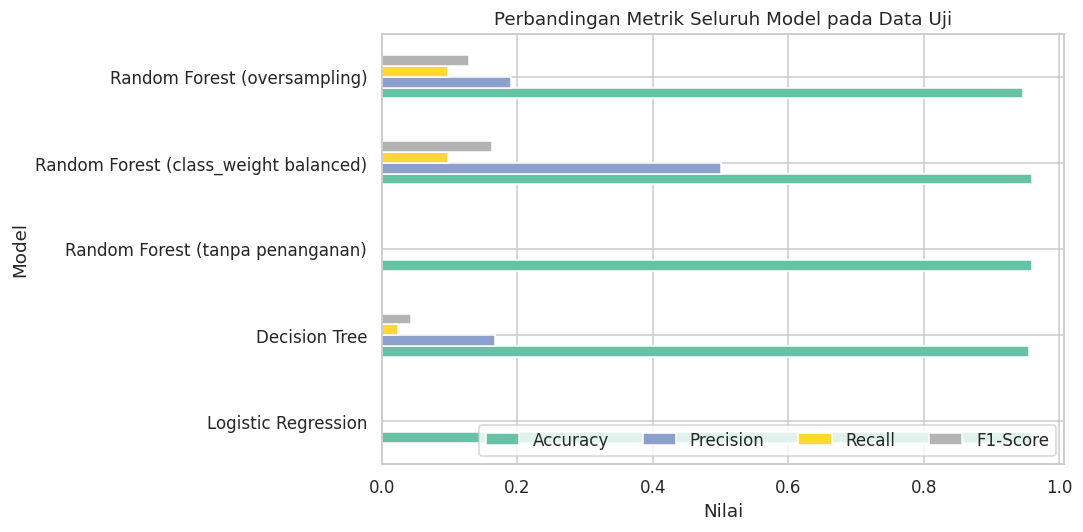

In [16]:
tabel[['Accuracy', 'Precision', 'Recall', 'F1-Score']].plot(
    kind='barh', figsize=(10, 5), colormap='Set2'
)
plt.title('Perbandingan Metrik Seluruh Model pada Data Uji')
plt.xlabel('Nilai')
plt.legend(loc='lower right', ncol=4)
plt.tight_layout()
plt.show()

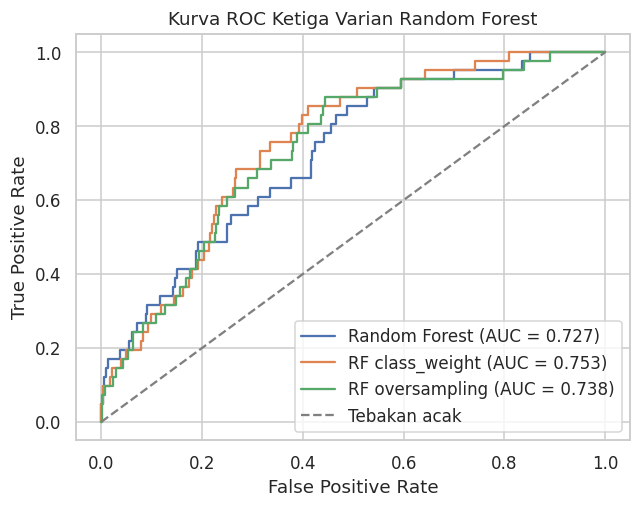

In [17]:
plt.figure(figsize=(6.5, 4.8))
for nama, proba in [
    ('Random Forest', proba_rf),
    ('RF class_weight', proba_rf_bobot),
    ('RF oversampling', proba_rf_os),
]:
    fpr, tpr, _ = roc_curve(y_test, proba)
    plt.plot(fpr, tpr, label=f'{nama} (AUC = {roc_auc_score(y_test, proba):.3f})')

plt.plot([0, 1], [0, 1], '--', color='grey', label='Tebakan acak')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Kurva ROC Ketiga Varian Random Forest')
plt.legend(loc='lower right')
plt.show()

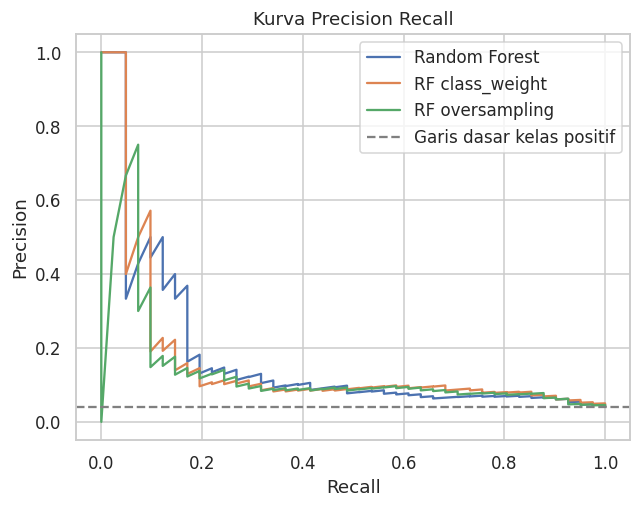

In [18]:
# Kurva Precision Recall lebih informatif daripada ROC pada data tidak seimbang
plt.figure(figsize=(6.5, 4.8))
for nama, proba in [
    ('Random Forest', proba_rf),
    ('RF class_weight', proba_rf_bobot),
    ('RF oversampling', proba_rf_os),
]:
    presisi, recall_, _ = precision_recall_curve(y_test, proba)
    plt.plot(recall_, presisi, label=nama)

plt.axhline(y_test.mean(), linestyle='--', color='grey', label='Garis dasar kelas positif')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Kurva Precision Recall')
plt.legend()
plt.show()

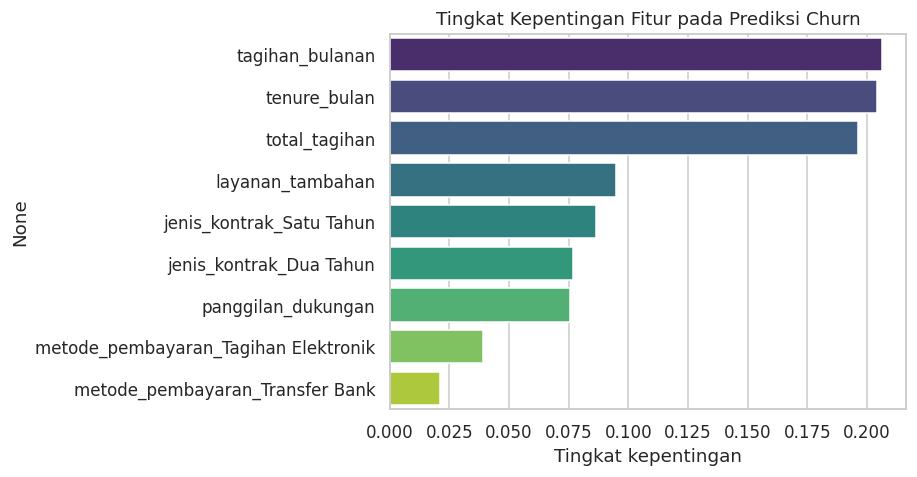

tagihan_bulanan                         0.2063
tenure_bulan                            0.2042
total_tagihan                           0.1961
layanan_tambahan                        0.0947
jenis_kontrak_Satu Tahun                0.0863
jenis_kontrak_Dua Tahun                 0.0770
panggilan_dukungan                      0.0756
metode_pembayaran_Tagihan Elektronik    0.0389
metode_pembayaran_Transfer Bank         0.0210
dtype: float64

In [19]:
# Faktor pendorong churn menurut Random Forest
kepentingan = pd.Series(rf_bobot.feature_importances_, index=X.columns).sort_values(ascending=False)

plt.figure(figsize=(8.5, 4.5))
sns.barplot(x=kepentingan.values, y=kepentingan.index, hue=kepentingan.index,
            palette='viridis', legend=False)
plt.title('Tingkat Kepentingan Fitur pada Prediksi Churn')
plt.xlabel('Tingkat kepentingan')
plt.tight_layout()
plt.show()

kepentingan.round(4)

## 11. Interpretasi Metrik untuk Kasus Customer Churn

Dataset churn ini bersifat tidak seimbang dengan kelas minoritas sekitar dua puluh
persen, sehingga **Accuracy saja jelas menyesatkan**. Model yang selalu menebak
"bertahan" memperoleh akurasi sekitar delapan puluh persen padahal tidak berhasil
menemukan satu pun pelanggan yang akan berhenti berlangganan.

Metrik yang paling relevan adalah **Recall pada kelas churn**, yaitu berapa persen
pelanggan yang benar benar berhenti berhasil terdeteksi lebih dahulu oleh model.
Alasannya bersifat bisnis, yaitu biaya membiarkan pelanggan pergi tanpa terdeteksi
(False Negative) jauh lebih besar daripada biaya memberi promosi retensi kepada
pelanggan yang sebenarnya tidak akan pergi (False Positive). Biaya akuisisi pelanggan
baru pada industri telekomunikasi umumnya beberapa kali lipat dibandingkan biaya
mempertahankan pelanggan lama.

Meskipun demikian Recall tidak boleh dikejar tanpa batas, karena model yang menandai
semua pelanggan sebagai churn akan membuat anggaran promosi terbuang percuma. Karena
itu **F1-Score** dipakai sebagai penyeimbang antara Precision dan Recall, sedangkan
kurva Precision Recall dipakai untuk memilih ambang keputusan yang sesuai dengan
kemampuan anggaran perusahaan.

Perbandingan pada tabel di atas memperlihatkan pola yang khas. Random Forest tanpa
penanganan menghasilkan Accuracy tertinggi namun Recall terendah, karena model
cenderung memihak kelas mayoritas. Setelah pembobotan kelas maupun oversampling
diterapkan, Accuracy turun sedikit tetapi Recall dan F1-Score pada kelas churn naik,
dan justru inilah model yang lebih berguna bagi perusahaan.

## 12. Kesimpulan

**Apa yang dipelajari.** Praktikum ini membahas metode ensemble Random Forest yang
menggabungkan banyak Decision Tree melalui prinsip bagging, serta dua strategi
penanganan dataset tidak seimbang berupa pembobotan kelas dan random oversampling
pada data latih. Studi kasus yang dipakai adalah Customer Churn Prediction.

**Temuan utama.** Random Forest mengungguli Decision Tree tunggal maupun Logistic
Regression pada hampir seluruh metrik, yang menunjukkan bahwa penggabungan banyak
model lemah memang menghasilkan model yang lebih kuat dan lebih stabil. Penanganan
ketidakseimbangan terbukti menaikkan Recall pada kelas churn dengan pengorbanan
berupa penurunan Accuracy yang relatif kecil, sehingga jumlah pelanggan berisiko yang
terlewat berkurang cukup banyak. Dari sisi faktor pendorong, masa berlangganan yang
pendek, jumlah panggilan ke layanan dukungan yang tinggi, serta kontrak bulanan
merupakan tiga penanda risiko churn yang paling kuat.

**Keterbatasan dan pertanyaan yang muncul.** Dataset yang dipakai bersifat sintetis
dengan hubungan antar variabel yang sengaja dirancang, sehingga performa model pada
data pelanggan sungguhan kemungkinan besar lebih rendah karena adanya derau dan
faktor yang tidak terekam. Random oversampling juga hanya menggandakan baris yang
sudah ada sehingga berisiko membuat model menghafal contoh minoritas, berbeda dengan
SMOTE yang membangkitkan data sintetis baru. Pertanyaan yang muncul adalah berapa
ambang keputusan yang paling menguntungkan bila biaya promosi retensi dan nilai
seumur hidup pelanggan dimasukkan ke dalam perhitungan, serta seberapa besar
peningkatan yang bisa diperoleh dari metode boosting seperti XGBoost.